In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
plt.rc('font',family='Malgun Gothic' )
!pip install koreanize-matplotlib
from IPython.display import display
import koreanize_matplotlib
import seaborn as sns


In [13]:
train data로 학습 후 test 예측 기온, 속도, 풍속 등

SyntaxError: invalid syntax (2399441674.py, line 1)

In [66]:
origin_train=pd.read_csv("train.csv")
origin_test=pd.read_csv("test.csv")
data_train=origin_train.copy()
data_test=origin_test.copy()


In [3]:
data_train

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,31/10/2018,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,31/10/2018,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,NaN,No Holiday,Yes
8037,31/10/2018,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,31/10/2018,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [4]:
data_train.isnull().sum()

Date                           0
Rented Bike Count              0
Hour                           0
Temperature(째C)              800
Humidity(%)                    0
Wind speed (m/s)             802
Visibility (10m)               0
Dew point temperature(째C)      0
Solar Radiation (MJ/m2)        0
Rainfall(mm)                   0
Snowfall (cm)                  0
Seasons                      802
Holiday                        0
Functioning Day                0
dtype: int64

In [5]:
data_test

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,30/11/2018,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,NaN,No Holiday,Yes
716,30/11/2018,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
717,30/11/2018,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
718,30/11/2018,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [5]:
data_test.isnull().sum()

Date                          0
Hour                          0
Temperature(째C)              76
Humidity(%)                   0
Wind speed (m/s)             74
Visibility (10m)              0
Dew point temperature(째C)     0
Solar Radiation (MJ/m2)       0
Rainfall(mm)                  0
Snowfall (cm)                 0
Seasons                      74
Holiday                       0
Functioning Day               0
dtype: int64

# 기상청 데이터를 이용해 결측치 채우기
 * https://data.kma.go.kr/data/grnd/selectAsosRltmList.do?pgmNo=36
 * https://www.weather.go.kr/w/resources/pdf/kma_data_portal_guide.pdf
 * 일단 이 데이터로 결측치를 채우기 적절한지 판단하기 위해 2가지 정도 생각해볼 수 있다.
   1. 결측치를 제외한 나머지 값들이 모두 동일한가?
   2. 결측치 부분에 적절한 값이 들어가 있는가?
   

# **기온 결측치 채우기**
![설명](이슬점공식.png)

- Dewpoint = 이슬점
- T = 기온
- RH = humidity

In [6]:
data_train.isnull().sum()

Date                           0
Rented Bike Count              0
Hour                           0
Temperature(째C)              800
Humidity(%)                    0
Wind speed (m/s)             802
Visibility (10m)               0
Dew point temperature(째C)      0
Solar Radiation (MJ/m2)        0
Rainfall(mm)                   0
Snowfall (cm)                  0
Seasons                      802
Holiday                        0
Functioning Day                0
dtype: int64

In [7]:
data_train["Date"]

0    01/12/2017
1    01/12/2017
2    01/12/2017
3    01/12/2017
4    01/12/2017
Name: Date, dtype: object

In [8]:
data_train["Date"].tail()

8035    31/10/2018
8036    31/10/2018
8037    31/10/2018
8038    31/10/2018
8039    31/10/2018
Name: Date, dtype: object

In [15]:
start=pd.to_datetime("2017-12-01")
end=pd.to_datetime("2018-10-31")

total_days=(end-start).days+1
total_days

335

In [16]:
335*24

8040

날짜 자체의 누락은 없는것을 확인.

## Temparature, Wind speed, Seasons 데이터 결측값 채우기

기상청데이터 불러오기

In [22]:
df_original=pd.read_csv("C:/Users/ekf44/Desktop/OBS_ASOS_TIM_20260206080127.csv",encoding="cp949")

In [23]:
df_original

,지점,지점명,일시,기온(°C),풍속(m/s)
0,108,서울,2017-12-01 00:00,-5.2,2.2
1,108,서울,2017-12-01 01:00,-5.5,0.8
2,108,서울,2017-12-01 02:00,-6.0,1.0
3,108,서울,2017-12-01 03:00,-6.2,0.9
4,108,서울,2017-12-01 04:00,-6.0,2.3
...,...,...,...,...,...
8035,108,서울,2018-10-31 19:00,8.4,1.0
8036,108,서울,2018-10-31 20:00,7.6,0.7
8037,108,서울,2018-10-31 21:00,7.6,3.0
8038,108,서울,2018-10-31 22:00,6.8,2.2


In [24]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   지점       8040 non-null   int64  
 1   지점명      8040 non-null   object 
 2   일시       8040 non-null   object 
 3   기온(°C)   8040 non-null   float64
 4   풍속(m/s)  8016 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 314.2+ KB


In [39]:
df_original.shape

(8040, 5)

In [40]:
data_train.shape

(8040, 14)

둘의 행개수가 일치함.

이제 원본데이터랑 train데이터랑 일치한지 확인

In [47]:
s1 = df_original['기온(°C)']
s2 = data_train['Temperature(째C)']

In [48]:
same_mask = (s1 == s2)

In [50]:
same_count = same_mask.sum()
different_count = (~same_mask).sum()

same_count, different_count

(np.int64(7240), np.int64(800))

결측값 만큼 다른것 확인

In [51]:
t1 = df_original['풍속(m/s)']
t2 = data_train['Wind speed (m/s)']

In [52]:
same_test = (t1 == t2)

In [55]:
same_count_1 = same_test.sum()
different_count_1 = (~same_test).sum()

same_count_1, different_count_1

(np.int64(7216), np.int64(824))

결측값개수 + original 데이터 결측값 개수 만큼 있는것 확인
- ( 802 + 24 면, 826인데 824인 이유는 아래 전처리를 먼저 하고 데이터 체크를 했음. )

In [25]:
df_original.isnull().sum()

지점          0
지점명         0
일시          0
기온(°C)      0
풍속(m/s)    24
dtype: int64

풍속에서 결측값이 있는것을 확인

In [26]:
df_original[df_original.isna().any(axis=1)]

,지점,지점명,일시,기온(°C),풍속(m/s)
107,108,서울,2017-12-05 11:00,-3.9,NaN
108,108,서울,2017-12-05 12:00,-2.3,NaN
109,108,서울,2017-12-05 13:00,-1.6,NaN
110,108,서울,2017-12-05 14:00,-1.1,NaN
111,108,서울,2017-12-05 15:00,-0.7,NaN
112,108,서울,2017-12-05 16:00,-0.5,NaN
113,108,서울,2017-12-05 17:00,-1.6,NaN
114,108,서울,2017-12-05 18:00,-2.6,NaN
115,108,서울,2017-12-05 19:00,-3.2,NaN
116,108,서울,2017-12-05 20:00,-3.5,NaN


In [29]:
missing_idx = df_original[df_original.isna().any(axis=1)].index

In [31]:
data_train.loc[missing_idx]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
107,05/12/2017,334,11,NaN,25,0.0,1959,-21.0,0.00,0.0,0.0,Winter,No Holiday,Yes
108,05/12/2017,321,12,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,Winter,No Holiday,Yes
109,05/12/2017,325,13,-1.6,27,0.0,1955,-18.2,0.00,0.0,0.0,Winter,No Holiday,Yes
110,05/12/2017,334,14,-1.1,28,0.0,2000,-17.3,0.00,0.0,0.0,Winter,No Holiday,Yes
111,05/12/2017,353,15,-0.7,28,0.0,2000,-16.9,0.00,0.0,0.0,Winter,No Holiday,Yes
112,05/12/2017,435,16,-0.5,30,0.0,2000,-16.0,0.00,0.0,0.0,Winter,No Holiday,Yes
113,05/12/2017,529,17,-1.6,35,0.0,2000,-15.1,0.00,0.0,0.0,NaN,No Holiday,Yes
114,05/12/2017,789,18,-2.6,40,0.0,2000,-14.4,0.00,0.0,0.0,Winter,No Holiday,Yes
115,05/12/2017,597,19,-3.2,45,0.0,2000,-13.5,0.00,0.0,0.0,NaN,No Holiday,Yes
116,05/12/2017,418,20,-3.5,46,0.0,2000,-13.4,0.00,0.0,0.0,Winter,No Holiday,Yes


train data에서도 풍속이 0이라 0으로 처리하고 시작.

In [76]:
target_idx = [118, 129]

data_train.loc[target_idx] = data_train.loc[target_idx].fillna(0)

In [33]:
data_train.loc[missing_idx]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
107,05/12/2017,334,11,NaN,25,0.0,1959,-21.0,0.00,0.0,0.0,Winter,No Holiday,Yes
108,05/12/2017,321,12,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,Winter,No Holiday,Yes
109,05/12/2017,325,13,-1.6,27,0.0,1955,-18.2,0.00,0.0,0.0,Winter,No Holiday,Yes
110,05/12/2017,334,14,-1.1,28,0.0,2000,-17.3,0.00,0.0,0.0,Winter,No Holiday,Yes
111,05/12/2017,353,15,-0.7,28,0.0,2000,-16.9,0.00,0.0,0.0,Winter,No Holiday,Yes
112,05/12/2017,435,16,-0.5,30,0.0,2000,-16.0,0.00,0.0,0.0,Winter,No Holiday,Yes
113,05/12/2017,529,17,-1.6,35,0.0,2000,-15.1,0.00,0.0,0.0,NaN,No Holiday,Yes
114,05/12/2017,789,18,-2.6,40,0.0,2000,-14.4,0.00,0.0,0.0,Winter,No Holiday,Yes
115,05/12/2017,597,19,-3.2,45,0.0,2000,-13.5,0.00,0.0,0.0,NaN,No Holiday,Yes
116,05/12/2017,418,20,-3.5,46,0.0,2000,-13.4,0.00,0.0,0.0,Winter,No Holiday,Yes


### Temparature

기온과 풍속은 일치하는지 테스트 했으므로 다 덮어쓰기로 시행

In [67]:
data_train['Temperature(째C)'].isnull().sum()

np.int64(800)

In [69]:
temp_mask = df_original['기온(°C)'].notna()

data_train.loc[temp_mask, 'Temperature(째C)'] = \
    df_original.loc[temp_mask, '기온(°C)']

In [71]:
data_train['Temperature(째C)'].isnull().sum()

np.int64(0)

### Wind speed

In [ ]:
data_train['Wind speed (m/s)'].isnull().sum() 

실수로 날아갔는데 np.int64(800) 나왔습니다.

In [78]:
wind_mask = df_original['풍속(m/s)'].notna()

data_train.loc[wind_mask, 'Wind speed (m/s)'] = \
    df_original.loc[wind_mask, '풍속(m/s)']

In [79]:
data_train['Wind speed (m/s)'].isnull().sum()

np.int64(0)

### Seasons

In [83]:
data_train[['Date','Seasons']]

,Date,Seasons
0,01/12/2017,NaN
1,01/12/2017,Winter
2,01/12/2017,Winter
3,01/12/2017,Winter
4,01/12/2017,Winter
...,...,...
8035,31/10/2018,Autumn
8036,31/10/2018,NaN
8037,31/10/2018,Autumn
8038,31/10/2018,Autumn


In [80]:
data_train['Seasons']

0          NaN
1       Winter
2       Winter
3       Winter
4       Winter
         ...  
8035    Autumn
8036       NaN
8037    Autumn
8038    Autumn
8039    Autumn
Name: Seasons, Length: 8040, dtype: object

In [84]:
data_train['Date'] = pd.to_datetime(data_train['Date'], dayfirst=True)

In [85]:
data_train['Month'] = data_train['Date'].dt.month

In [89]:
data_train[['Date', 'Month', 'Seasons']].head(10)

,Date,Month,Seasons
0,2017-12-01,12,NaN
1,2017-12-01,12,Winter
2,2017-12-01,12,Winter
3,2017-12-01,12,Winter
4,2017-12-01,12,Winter
5,2017-12-01,12,Winter
6,2017-12-01,12,Winter
7,2017-12-01,12,Winter
8,2017-12-01,12,Winter
9,2017-12-01,12,Winter


In [90]:
data_train[['Date', 'Month', 'Seasons']].tail(10)

,Date,Month,Seasons
8030,2018-10-31,10,NaN
8031,2018-10-31,10,Autumn
8032,2018-10-31,10,Autumn
8033,2018-10-31,10,Autumn
8034,2018-10-31,10,Autumn
8035,2018-10-31,10,Autumn
8036,2018-10-31,10,NaN
8037,2018-10-31,10,Autumn
8038,2018-10-31,10,Autumn
8039,2018-10-31,10,Autumn


In [88]:
pd.crosstab(data_train['Month'], data_train['Seasons'])

Seasons,Autumn,Spring,Summer,Winter
Month,,,,
1,0,0,0,660
2,0,0,0,611
3,0,677,0,0
4,0,643,0,0
5,0,670,0,0
6,0,0,645,0
7,0,0,680,0
8,0,0,665,0
9,650,0,0,0


각 월별로 봄,여름,가을,겨울이 나뉘어져 있으므로, 월을 기준으로 결측치 채우기
 - 12,1,2 겨울, 3,4,5 봄, 6,7,8 여름 9,10 가을

In [92]:
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

data_train['Seasons'] = data_train['Month'].map(season_map)

In [93]:
pd.crosstab(data_train['Month'], data_train['Seasons'])

Seasons,Autumn,Spring,Summer,Winter
Month,,,,
1,0,0,0,744
2,0,0,0,672
3,0,744,0,0
4,0,720,0,0
5,0,744,0,0
6,0,0,720,0
7,0,0,744,0
8,0,0,744,0
9,720,0,0,0


In [94]:
data_train['Seasons'].isnull().sum()

np.int64(0)

In [95]:
data_train

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Month,Season_rule
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Winter
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Winter
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Winter
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Winter
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-10-31,1507,19,8.4,53,1.0,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes,10,Autumn
8036,2018-10-31,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes,10,Autumn
8037,2018-10-31,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes,10,Autumn
8038,2018-10-31,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,10,Autumn


In [96]:
data_train.drop(columns=['Month', 'Season_rule'], inplace=True)

In [97]:
data_train

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-10-31,1507,19,8.4,53,1.0,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,2018-10-31,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8037,2018-10-31,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,2018-10-31,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [99]:
data_test

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,30/11/2018,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,NaN,No Holiday,Yes
716,30/11/2018,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
717,30/11/2018,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
718,30/11/2018,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


# 변수들 분석하기

### Hour

In [100]:
data_train['Hour'].value_counts().sort_index()

Hour
0     335
1     335
2     335
3     335
4     335
5     335
6     335
7     335
8     335
9     335
10    335
11    335
12    335
13    335
14    335
15    335
16    335
17    335
18    335
19    335
20    335
21    335
22    335
23    335
Name: count, dtype: int64

In [101]:
hour_mean = data_train.groupby('Hour')['Rented Bike Count'].mean()
hour_mean

Hour
0      547.307463
1      429.650746
2      304.826866
3      205.262687
4      133.791045
5      141.110448
6      290.238806
7      604.826866
8     1002.683582
9      641.728358
10     526.376119
11     600.346269
12     699.752239
13     734.232836
14     760.704478
15     832.638806
16     936.698507
17    1146.785075
18    1514.573134
19    1213.970149
20    1091.002985
21    1053.498507
22     939.161194
23     683.456716
Name: Rented Bike Count, dtype: float64

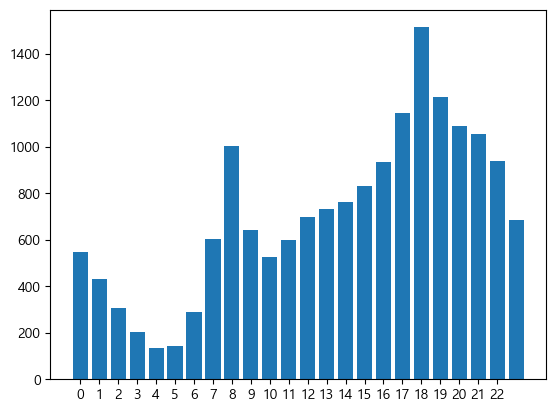

In [104]:
plt.figure()
plt.bar(hour_mean.index, hour_mean.values)
plt.xticks(range(0, 23))
plt.show()

변수 인사이트 정리
 - 보면, 시간대에 따라 따릉이 대여량이 다른 것을 볼 수 있다. 특히, 07~09시 출근시간대와 17~19시 퇴근시간 쯤에 대여량이 높아지는 bimodal 구조를 가지고 있다.
    

### Temparature

In [106]:
data_train['Temperature(째C)'].describe()

count    8040.000000
mean       13.337301
std        12.292018
min       -17.800000
25%         3.200000
50%        15.350000
75%        23.200000
max        39.400000
Name: Temperature(째C), dtype: float64

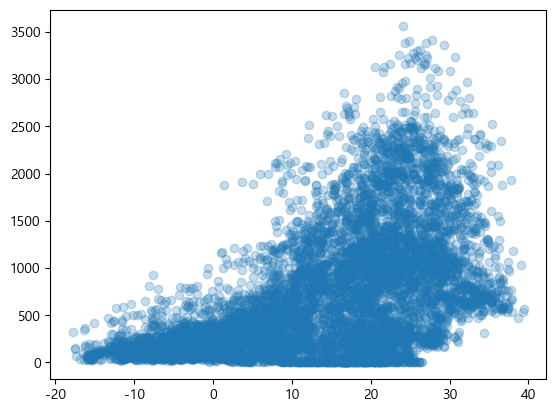

In [108]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    data_train['Temperature(째C)'],
    data_train['Rented Bike Count'],
    alpha=0.25
)
plt.show()

C:\Users\ekf44\AppData\Local\Temp\ipykernel_24712\2320916686.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_mean = data_train.groupby(temp_bins)['Rented Bike Count'].mean()


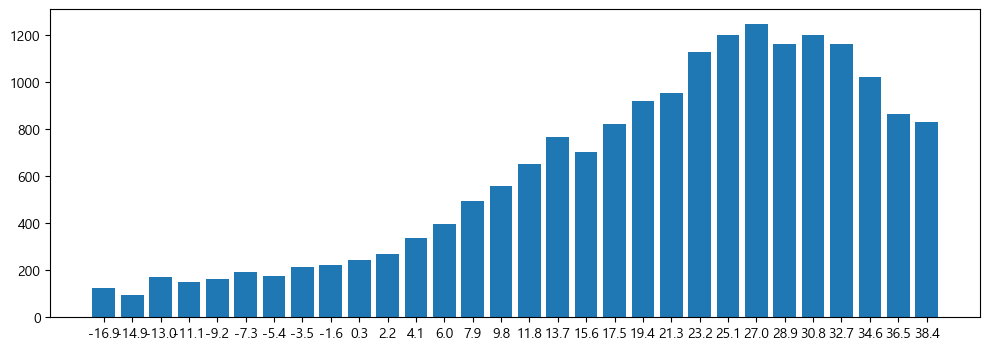

In [114]:
temp_bins = pd.cut(
    data_train['Temperature(째C)'],
    bins=30
)

temp_mean = data_train.groupby(temp_bins)['Rented Bike Count'].mean()

labels = [
    f"{round(interval.mid, 1)}"
    for interval in temp_mean.index
]

plt.figure(figsize=(12, 4))
plt.bar(labels, temp_mean.values)
plt.show()


변수 인사이트 정리
 - 온도가 낮을 때 따릉이를 덜 타는 경향을 보이고, 온도가 높아질 수록 따릉이 사용률이 올라가다가 온도가 일정부분 높아지면 다시 사용률이 떨어지는 모습을 보여준다.

### Humidity

In [115]:
data_train['Humidity(%)'].describe()

count    8040.000000
mean       58.271020
std        20.340492
min         0.000000
25%        43.000000
50%        57.000000
75%        74.000000
max        98.000000
Name: Humidity(%), dtype: float64

최솟값인 0, 즉 습도가 0이 나올 수가 없는데 나왔으므로, 이를 처리해준다.

In [116]:
humidity_zero_mask = data_train['Humidity(%)'] == 0

humidity_zero_mask.sum()

np.int64(17)

In [117]:
T = data_train.loc[humidity_zero_mask, 'Temperature(째C)']
DP = data_train.loc[humidity_zero_mask, 'Dew point temperature(째C)']

humidity_estimated = 100 * np.exp(
    (17.625 * DP / (243.04 + DP)) -
    (17.625 * T  / (243.04 + T))
)

In [118]:
data_train.loc[humidity_zero_mask, 'Humidity(%)'] = humidity_estimated

C:\Users\ekf44\AppData\Local\Temp\ipykernel_24712\3050570662.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[62.54570589 33.05165846 34.02545389 33.0997281  36.03446574 39.22261653
 35.09835974 71.6478836  71.66654008 71.68517956 71.6478836  59.8271227
 55.93181987 57.75160519 63.73652129 63.64671279 59.63491668]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_train.loc[humidity_zero_mask, 'Humidity(%)'] = humidity_estimated


In [119]:
data_train['Humidity(%)'].describe()

count    8040.000000
mean       58.385479
std        20.175395
min        10.000000
25%        43.000000
50%        57.000000
75%        74.000000
max        98.000000
Name: Humidity(%), dtype: float64

In [120]:
humidity_zero_mask = data_train['Humidity(%)'] == 0

humidity_zero_mask.sum()

np.int64(0)

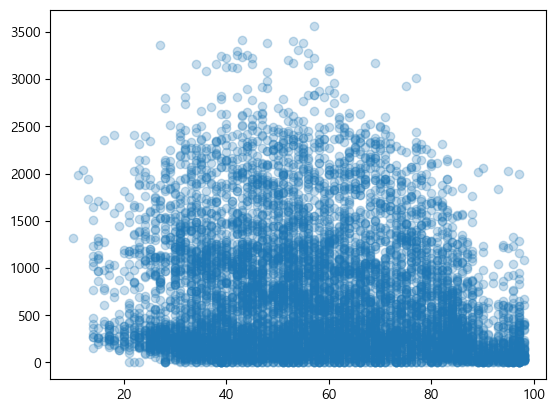

In [122]:
plt.figure()
plt.scatter(
    data_train['Humidity(%)'],
    data_train['Rented Bike Count'],
    alpha=0.25
)
plt.show()

C:\Users\ekf44\AppData\Local\Temp\ipykernel_24712\4227186861.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hum_mean = data_train.groupby(hum_bins)['Rented Bike Count'].mean()


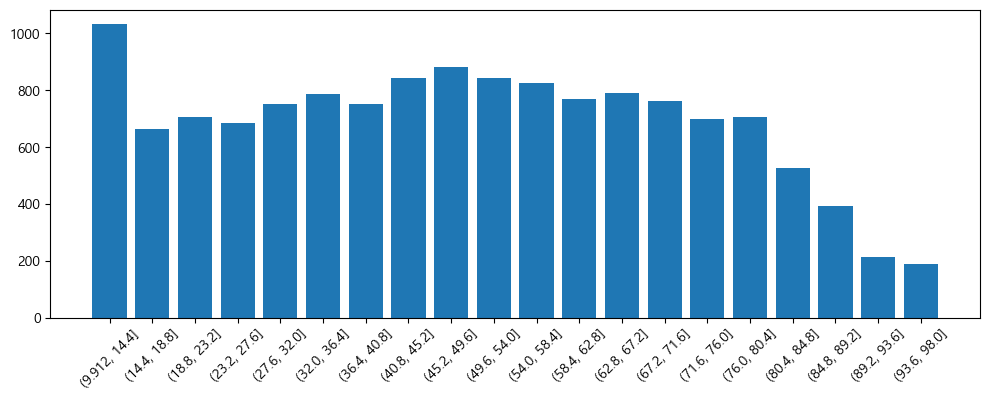

In [123]:
hum_bins = pd.cut(
    data_train['Humidity(%)'],
    bins=20
)

hum_mean = data_train.groupby(hum_bins)['Rented Bike Count'].mean()

plt.figure(figsize=(12, 4))
plt.bar(
    hum_mean.index.astype(str),
    hum_mean.values
)
plt.xticks(rotation=45)
plt.show()

변수 인사이트 정리
 - 되게 평탄한 구조를 보인다. 특히, 습도가 굉장히 높을 때는 비가 오는 경우이므로 급격히 낮아지는 경향을 보인다.

### Wind speed

In [131]:
data_train['Wind speed (m/s)'].describe()

count    8040.000000
mean        1.755336
std         1.046664
min         0.000000
25%         1.000000
50%         1.600000
75%         2.400000
max         7.400000
Name: Wind speed (m/s), dtype: float64

In [126]:
wind_bins = [-0.1, 0, 1, 2, 3, 4, 5, data_train['Wind speed (m/s)'].max()]
wind_labels = ['0', '1', '2', '3', '4', '5', '6+']

data_train['Wind_bin'] = pd.cut(
    data_train['Wind speed (m/s)'],
    bins=wind_bins,
    labels=wind_labels
)

C:\Users\ekf44\AppData\Local\Temp\ipykernel_24712\2838229907.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Wind_bin')['Rented Bike Count']


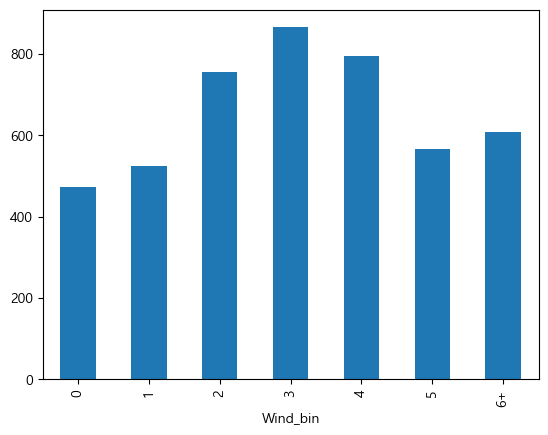

In [127]:
wind_grouped = (
    data_train
    .groupby('Wind_bin')['Rented Bike Count']
    .mean()
)

wind_grouped.plot(kind='bar')
plt.show()


변수 인사이트 정리
 - 풍속이 2~4m/s 정도일 때 대여량이 많은 것을 보여준다.

### Visibility

In [130]:
data_train['Visibility (10m)'].describe()

count    8040.000000
mean     1459.170896
std       603.716284
min        27.000000
25%       977.000000
50%      1741.000000
75%      2000.000000
max      2000.000000
Name: Visibility (10m), dtype: float64

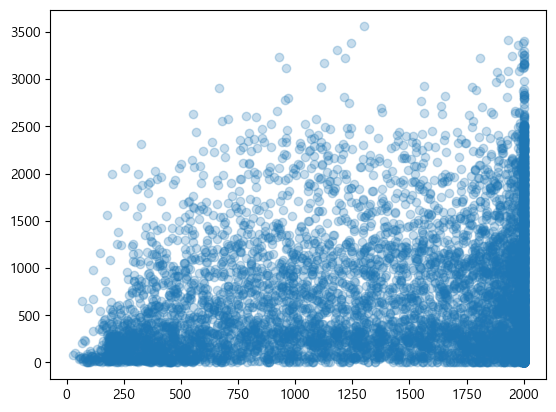

In [132]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    data_train['Visibility (10m)'],
    data_train['Rented Bike Count'],
    alpha=0.25
)
plt.show()


C:\Users\ekf44\AppData\Local\Temp\ipykernel_24712\2729987162.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vis_mean = data_train.groupby(vis_bins)['Rented Bike Count'].mean()


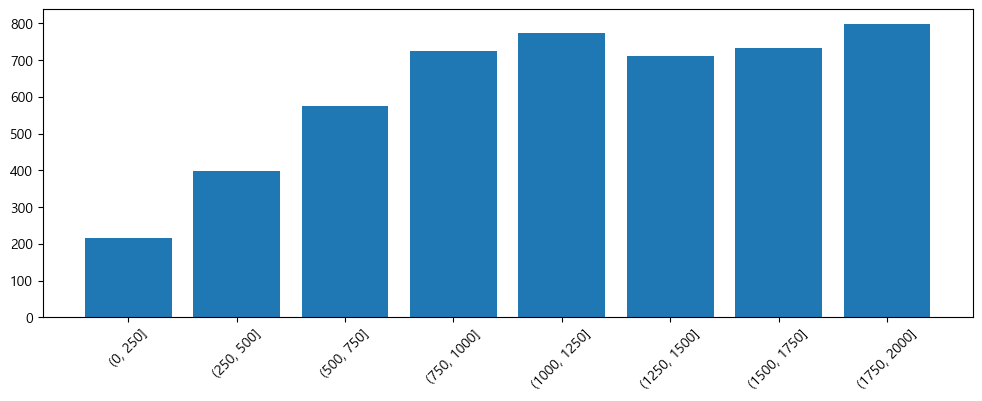

In [136]:
vis_bins = pd.cut(
    data_train['Visibility (10m)'],
    bins=[0, 250, 500, 750, 1000, 1250, 1500, 1750, data_train['Visibility (10m)'].max()]
)

vis_mean = data_train.groupby(vis_bins)['Rented Bike Count'].mean()

plt.figure(figsize=(12,4))
plt.bar(
    vis_mean.index.astype(str),
    vis_mean.values
)
plt.xticks(rotation=45)
plt.show()

변수 인사이트 정리
 - Visibility가 낮을수록 대여량이 낮았는데 750~1000구간부터 평탄하게 따릉이를 타는 정도가 일정하게 일어난다.

### Solar Radiation

In [138]:
data_train['Solar Radiation (MJ/m2)'].describe()

count    8040.000000
mean        0.587072
std         0.886186
min         0.000000
25%         0.000000
50%         0.020000
75%         0.960000
max         3.520000
Name: Solar Radiation (MJ/m2), dtype: float64

In [141]:
solar_day = data_train.groupby(data_train['Solar Radiation (MJ/m2)'] > 0)['Rented Bike Count'].mean()

solar_day

Solar Radiation (MJ/m2)
False    484.498972
True     920.939277
Name: Rented Bike Count, dtype: float64

Solar Radiation이 낮과 밤정도의 시간 비율로 나누어져있다.

In [142]:
solar_positive = data_train[data_train['Solar Radiation (MJ/m2)'] > 0]

C:\Users\ekf44\AppData\Local\Temp\ipykernel_24712\2361439128.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  solar_mean = solar_positive.groupby(solar_bins)['Rented Bike Count'].mean()


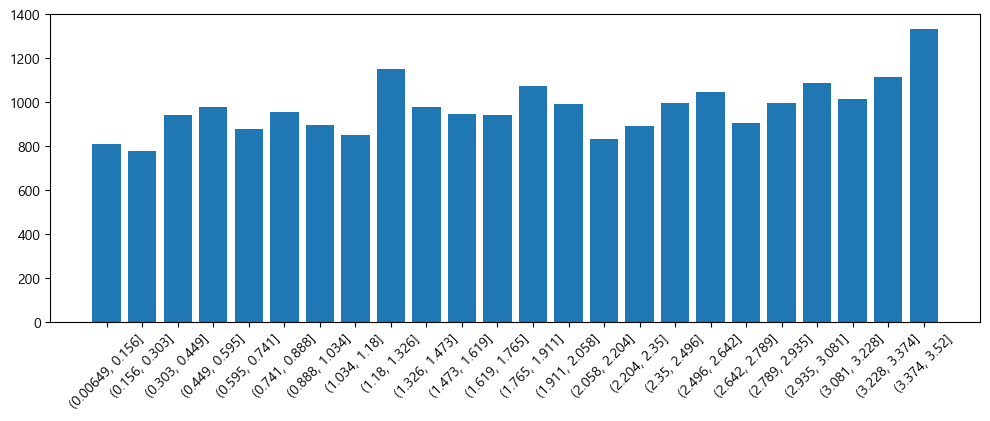

In [145]:
solar_bins = pd.cut(
    solar_positive['Solar Radiation (MJ/m2)'],
    bins=24
)

solar_mean = solar_positive.groupby(solar_bins)['Rented Bike Count'].mean()

plt.figure(figsize=(12,4))
plt.bar(
    solar_mean.index.astype(str),
    solar_mean.values
)
plt.xticks(rotation=45)
plt.show()

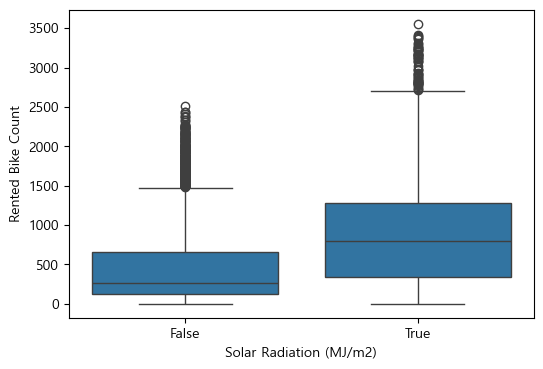

In [146]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x=data_train['Solar Radiation (MJ/m2)'] > 0,
    y=data_train['Rented Bike Count']
)
plt.show()

변수 인사이트 정리
 - Solar Radiation이 낮과 밤의 경계 역할도 할 수 있음을 알 수 있으며, 특히 밤일 경우(Solar Radiation이 0일 경우) 대여량이 상당히 낮은 것을 볼 수 있다.

### Rainfall

In [147]:
rain_binary = data_train.groupby(data_train['Rainfall(mm)'] > 0)['Rented Bike Count'].mean()

rain_binary

Rainfall(mm)
False    746.725196
True     165.371820
Name: Rented Bike Count, dtype: float64

비가 오는날과 오지 않은 날을 구분해준다.

In [148]:
rain_positive = data_train[data_train['Rainfall(mm)'] > 0]

C:\Users\ekf44\AppData\Local\Temp\ipykernel_24712\1578387349.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rain_mean = rain_positive.groupby(rain_bins)['Rented Bike Count'].mean()


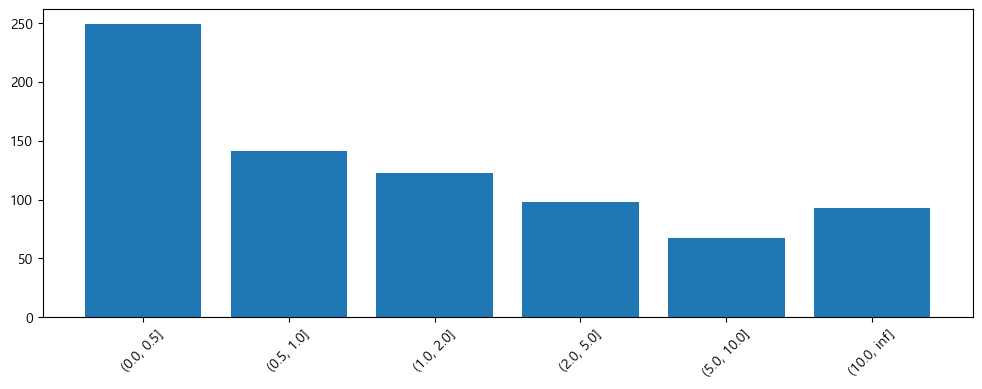

In [151]:
rain_bins = pd.cut(
    rain_positive['Rainfall(mm)'],
    bins=[0, 0.5, 1, 2, 5, 10, float('inf')]
)

rain_mean = rain_positive.groupby(rain_bins)['Rented Bike Count'].mean()

plt.figure(figsize=(12,4))
plt.bar(
    rain_mean.index.astype(str),
    rain_mean.values
)
plt.xticks(rotation=45)
plt.show()

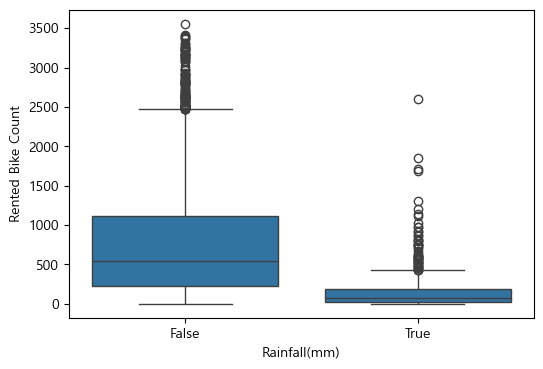

In [152]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x=data_train['Rainfall(mm)'] > 0,
    y=data_train['Rented Bike Count']
)
plt.show()

확실히 비가 올때와 오지 않을때 대여량의 차이가 크다는 것을 알 수 있다.

In [150]:
data_train['Rain'] = (data_train['Rainfall(mm)'] > 0).astype(int)

비가 올때와 안올때의 파생변수 생성

변수 인사이트 정리
 - 강수량이 있을때와 있지 않을 때 따릉이 대여량의 차이가 크다는 것을 알 수 있으며, 비가 오지 않을 때의 따릉이 대여량이 훨씬 높다.

### Snowfall

In [154]:
snow_freq = data_train['Snowfall (cm)'] > 0
snow_freq.value_counts()

Snowfall (cm)
False    7648
True      392
Name: count, dtype: int64

눈이 온 날과 오지 않은 날을 구분해준다.

In [155]:
snow_summary = data_train.assign(
    Snow = data_train['Snowfall (cm)'] > 0).groupby('Snow').agg(mean_rent=('Rented Bike Count', 'mean'),
    count=('Rented Bike Count', 'count')
)

snow_summary

,mean_rent,count
Snow,,
False,738.093096,7648
True,157.303571,392


In [157]:
data_train['Snow'] = (data_train['Snowfall (cm)'] > 0).astype(int)

snow_mean = data_train.groupby('Snow')['Rented Bike Count'].mean()
snow_count = data_train['Snow'].value_counts().sort_index()

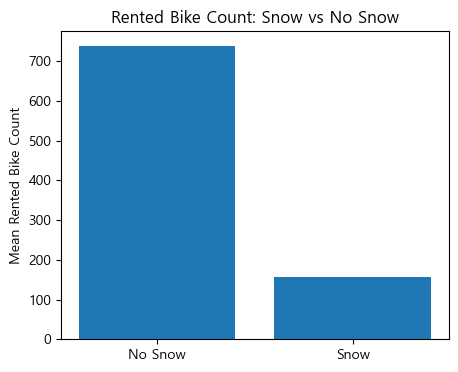

In [158]:
plt.figure(figsize=(5,4))
plt.bar(['No Snow', 'Snow'], snow_mean.values)
plt.ylabel('Mean Rented Bike Count')
plt.title('Rented Bike Count: Snow vs No Snow')
plt.show()

눈이 안왔을때의 따릉이 대여량이 확실히 많다는 것을 알 수 있다

변수 인사이트 정리
 - Rainfall(강수량)과 마찬가지로 비와 눈의 유무가 따릉이 대여량의 큰 영향을 끼친다는 것을 알 수 있다. Snowfall 또한 눈이 오지 않을 때의 따릉이 대여량이 확실히 많다.

### Seasons

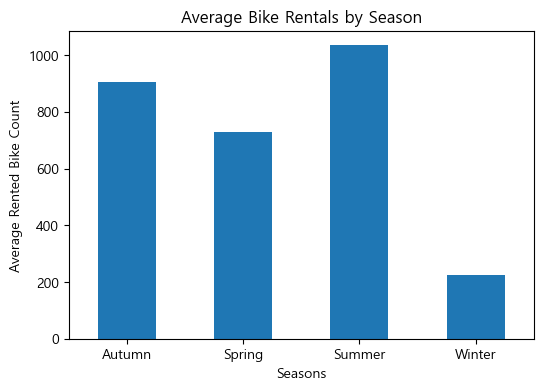

In [163]:
season_mean = (
    data_train
    .groupby('Seasons')['Rented Bike Count']
    .mean()
)

plt.figure(figsize=(6,4))
season_mean.plot(kind='bar')
plt.ylabel('Average Rented Bike Count')
plt.title('Average Bike Rentals by Season')
plt.xticks(rotation=0)
plt.show()

 변수 인사이트 정리
 - 확실히 눈이 많이 오는 겨울에 따릉이 대여량이 줄어드는 것을 볼 수 있다. 여름의 경우는 날씨와 일조량으로 인해 제일 대여량이 많은 것으로 보인다.

### Holiday / Functioning Day

이 둘을 합쳐서 1/0 구조로 만들어준다

In [177]:
data_train['Holiday'].value_counts().sort_index()

Holiday
Holiday        432
No Holiday    7608
Name: count, dtype: int64

In [176]:
data_train['Functioning Day'].value_counts().sort_index()

Functioning Day
No      223
Yes    7817
Name: count, dtype: int64

조사해본 결과, Holiday는 법정 공휴일이고, Functioning Day는 실질직으로 운영을 했는지 안했는지이므로 한 변수로 묶지 않고 그대로 두고 분석해준다.

<Axes: xlabel='Rented Bike Count', ylabel='Holiday'>

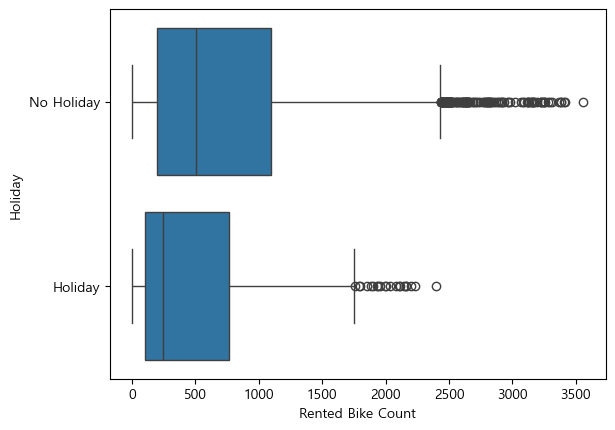

In [181]:
sns.boxplot(x='Rented Bike Count',y='Holiday',data=data_train)

<Axes: xlabel='Rented Bike Count', ylabel='Functioning Day'>

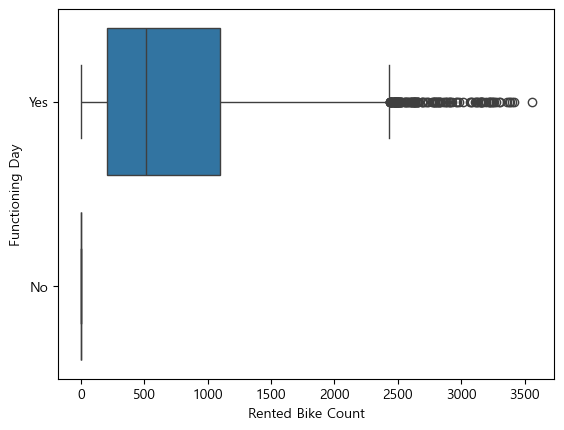

In [182]:
sns.boxplot(x='Rented Bike Count',y='Functioning Day',data=data_train)

변수 인사이트 정리
 - 일하는 날에 따릉이 이용 비중이 큰 것으로 보여진다. 이를 통해 출퇴근용으로 따릉이를 사용하는 경우가 많다는 것을 알 수 있으며, 일하는 날에 따릉이를 사용하는 비율이 높다는 것을 알 수 있다.

## 모델링

모델로는 Random Forest를 채택하였다.
 - 온도, 시간, 계절처럼 비선형인 관계에 강하며, 이상치에 비교적 둔감하기 때문이다.
 - Random Forest 자체가, 지금의 데이터 처럼 환경 변수가 많은 문제에 적합하기 때문이다.

In [188]:
data_train

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Wind_bin,Rain,Snow,Active_Day
0,2017-12-01,254,0,-5.2,37.0,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,3,0,0,0
1,2017-12-01,204,1,-5.5,38.0,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,0,0,0
2,2017-12-01,173,2,-6.0,39.0,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,0,0,0
3,2017-12-01,107,3,-6.2,40.0,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,0,0,0
4,2017-12-01,78,4,-6.0,36.0,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-10-31,1507,19,8.4,53.0,1.0,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes,1,0,0,0
8036,2018-10-31,1176,20,7.6,59.0,0.7,2000,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes,1,0,0,0
8037,2018-10-31,1069,21,7.6,59.0,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes,3,0,0,0
8038,2018-10-31,1088,22,6.8,58.0,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,3,0,0,0


Seasons들 1,2,3,4로 바꾸기

In [199]:
season_map = {
    'Spring': 1,
    'Summer': 2,
    'Autumn': 3,
    'Winter': 4
}

In [200]:
data_train['Seasons'] = data_train['Seasons'].map(season_map)

In [201]:
data_train['Seasons'].value_counts().sort_index()

Seasons
1    2208
2    2208
3    1464
4    2160
Name: count, dtype: int64

In [211]:
data_test['Seasons'] = data_test['Seasons'].map(season_map)

In [212]:
data_test['Seasons'].value_counts().sort_index()

Seasons
3.0    646
Name: count, dtype: int64

In [213]:
X_train = data_train[['Hour','Temperature(째C)','Humidity(%)','Wind speed (m/s)','Visibility (10m)',
                      'Dew point temperature(째C)','Solar Radiation (MJ/m2)','Rainfall(mm)',
                      'Snowfall (cm)','Seasons']]
Y_train = data_train['Rented Bike Count']

In [234]:
X_test = data_test[['Hour','Temperature(째C)','Humidity(%)','Wind speed (m/s)','Visibility (10m)',
                      'Dew point temperature(째C)','Solar Radiation (MJ/m2)','Rainfall(mm)',
                      'Snowfall (cm)','Seasons']]

In [238]:
from sklearn.ensemble import RandomForestRegressor

In [239]:
from sklearn.model_selection import train_test_split

X = data_train[['Hour','Temperature(째C)','Humidity(%)','Wind speed (m/s)','Visibility (10m)',
                      'Dew point temperature(째C)','Solar Radiation (MJ/m2)','Rainfall(mm)',
                      'Snowfall (cm)','Seasons']]
y = data_train['Rented Bike Count']

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [244]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_tr, y_tr)

,n_estimators,300
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [245]:
y_tr_pred = model.predict(X_tr)

y_val_pred = model.predict(X_val)

In [246]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_train = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
print("학습 RMSE :", rmse_train)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print("검증 RMSE :", rmse_val)

print("학습 MAE  :", mean_absolute_error(y_tr, y_tr_pred))
print("검증 MAE  :", mean_absolute_error(y_val, y_val_pred))

print("학습 R2   :", r2_score(y_tr, y_tr_pred))
print("검증 R2   :", r2_score(y_val, y_val_pred))

학습 RMSE : 320.57466741679826
검증 RMSE : 315.29129050757786
학습 MAE  : 199.3033255968893
검증 MAE  : 197.06229611476604
학습 R2   : 0.7611885792924227
검증 R2   : 0.7734002963046918


과적합 거의 없이 잘 일반화가 되었으나, 설명력이 좀 약함.

In [224]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [225]:
from sklearn.metrics import accuracy_score

In [226]:
Y_train_pred = model.predict(X_train)

In [227]:
Y_test_pred = model.predict(X_test)

In [233]:
t = pd.DataFrame({'Rented Bike Count': Y_test_pred})

t.to_csv("C:/Users/ekf44/Desktop/따릉이 예측값.csv", index=False)